In [1]:
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install wordcloud
import pandas as pd
import numpy as np
import spacy
import nltk
nlp = spacy.load("en_core_web_sm")
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import string
from nltk.corpus import stopwords
nltk.download('all')
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import warnings
warnings.filterwarnings('ignore')

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 797.8 kB/s eta 0:00:16
     -- ------------------------------------ 0.8/12.8 MB 860.4 kB/s eta 0:00:14
     ---- ----------------------------------- 1.6/12.8 MB 1.4 MB/s eta 0:00:08
     ----- ---------------------------------- 1.8/12.8 MB 1.6 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 1.5 MB/s eta 0:00:08
     ------- -------------------------------- 2.4/12.8 MB 1.4 MB/s eta 0:00:08
     ------- -------------------------------- 2.4/12.8 MB 1.4 MB/s eta 0:00:08
     ------- -------------------------------- 2.4/12.8 MB 1.4 MB/s eta 0:00:08
     --------- ------------------------------ 2.9/12.8 MB 1.3 MB/s eta 0:00:08

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[

In [2]:
df = pd.read_excel("dataset -P667.xlsx")
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [3]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [4]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['len'] = df.body.apply(len)

In [7]:
df.head()

,title,rating,body,len
0,Horrible product,1,Very disappointed with the overall performance...,59
1,Camera quality is not like 48 megapixel,3,Camera quality is low,21
2,Overall,4,"Got the mobile on the launch date,Battery must...",403
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,377
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",179


# cleaning data

In [8]:
def clean_text(text):
    doc = nlp(str(text).lower())
    
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop 
        and not token.is_punct 
        and token.is_alpha
    ]
    
    return " ".join(tokens)

df['clean_review'] = df['body'].apply(clean_text)

In [9]:
df.to_csv("cleaned_reviews.csv", index=False)
print("Cleaned CSV file saved successfully.")

Cleaned CSV file saved successfully.


In [10]:
df[['body', 'clean_review']].head()

,body,clean_review
0,Very disappointed with the overall performance...,disappointed overall performance samsung
1,Camera quality is low,camera quality low
2,"Got the mobile on the launch date,Battery must...",get mobile launch date battery appreciatedcame...
3,1. It doesn't work with 5.0GHz WiFi frequency....,work wifi frequency old camera quality patheti...
4,"Not worth buying....faulty software, poor disp...",worth buy faulty software poor display quality...


In [11]:
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))
df['word_count'].describe()

count    1440.000000
mean       24.944444
std        18.057001
min         1.000000
25%        14.000000
50%        21.000000
75%        29.000000
max       212.000000
Name: word_count, dtype: float64

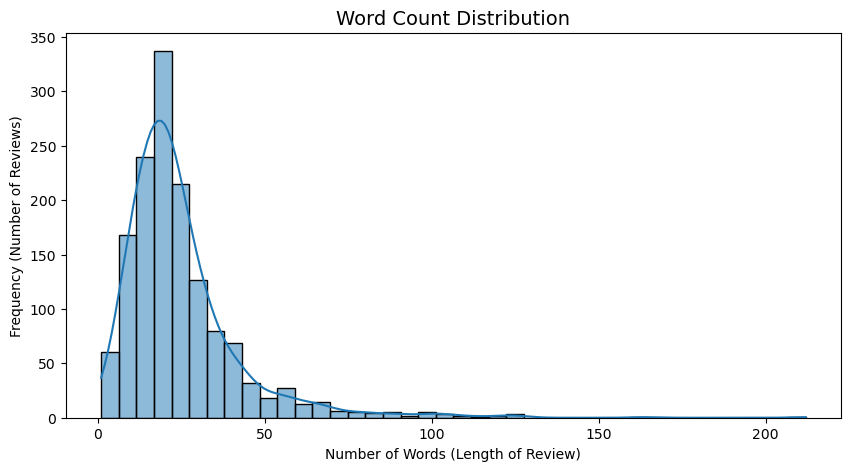

In [12]:
import seaborn as sns
plt.figure(figsize=(10,5))

sns.histplot(df['word_count'], bins=40, kde=True)

plt.title("Word Count Distribution", fontsize=14)
plt.xlabel("Number of Words (Length of Review)")
plt.ylabel("Frequency (Number of Reviews)")

plt.show()

# most Frequent Words

In [13]:
from collections import Counter

all_words = " ".join(df['clean_review']).split()

common_words = Counter(all_words).most_common(20)

print(common_words)

[('phone', 1568), ('good', 1257), ('camera', 873), ('battery', 724), ('samsung', 630), ('quality', 610), ('mobile', 519), ('buy', 418), ('price', 339), ('day', 332), ('product', 315), ('like', 291), ('life', 281), ('display', 266), ('work', 265), ('bad', 254), ('well', 238), ('use', 238), ('screen', 225), ('time', 211)]


# Plot Top Words

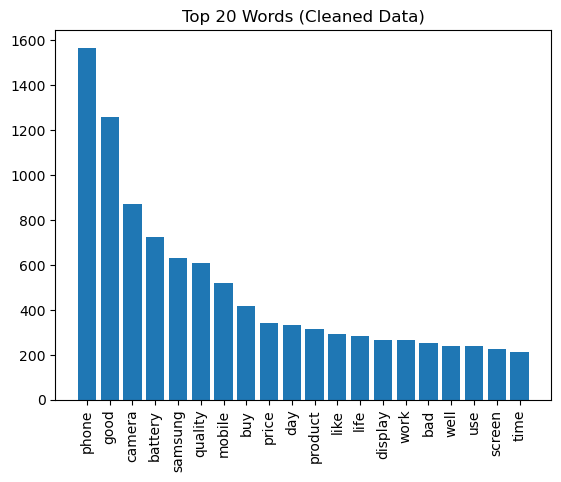

In [14]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Words (Cleaned Data)")
plt.show()

# Word Cloud(for presentstion)

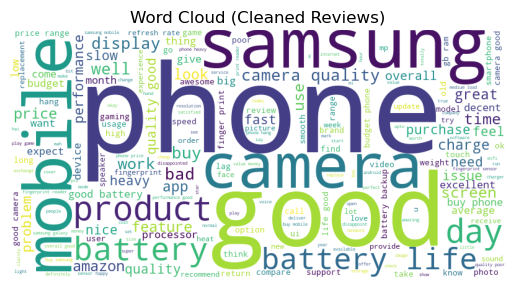

In [15]:
text = " ".join(df['clean_review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud (Cleaned Reviews)")
plt.show()

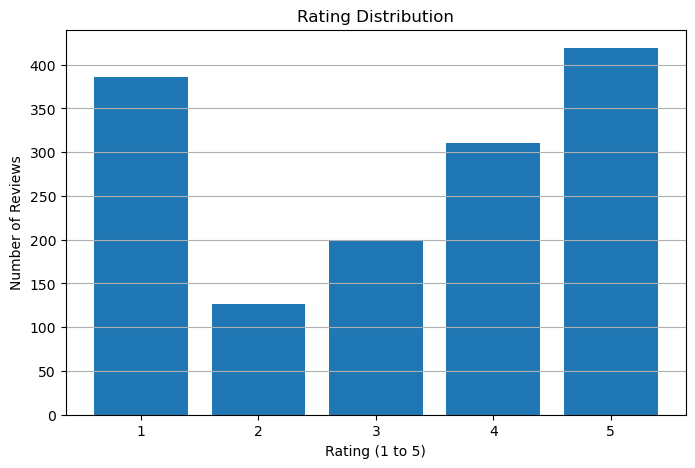

In [16]:
# Count ratings
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Rating Distribution")
plt.xlabel("Rating (1 to 5)")                 # X-axis → categories
plt.ylabel("Number of Reviews")               # Y-axis → frequency

plt.xticks([1,2,3,4,5])                       # show all ratings clearly
plt.grid(axis='y')

plt.show()

In [17]:
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)
df['sentiment'].head()

0    Negative
1     Neutral
2    Positive
3    Negative
4    Negative
Name: sentiment, dtype: object

In [18]:
df["sentiment"].value_counts()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

In [19]:
from collections import Counter

for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]
    words = " ".join(subset['clean_review']).split()
    
    print(f"\nTop words in {sentiment}:")
    print(Counter(words).most_common(10))


Top words in Negative:
[('phone', 574), ('samsung', 289), ('mobile', 252), ('buy', 226), ('camera', 215), ('quality', 194), ('bad', 194), ('product', 169), ('amazon', 151), ('good', 147)]

Top words in Neutral:
[('phone', 233), ('good', 167), ('camera', 141), ('quality', 105), ('battery', 95), ('mobile', 85), ('samsung', 81), ('buy', 49), ('average', 46), ('well', 44)]

Top words in Positive:
[('good', 943), ('phone', 761), ('camera', 517), ('battery', 489), ('quality', 311), ('samsung', 260), ('price', 241), ('life', 202), ('day', 194), ('mobile', 182)]


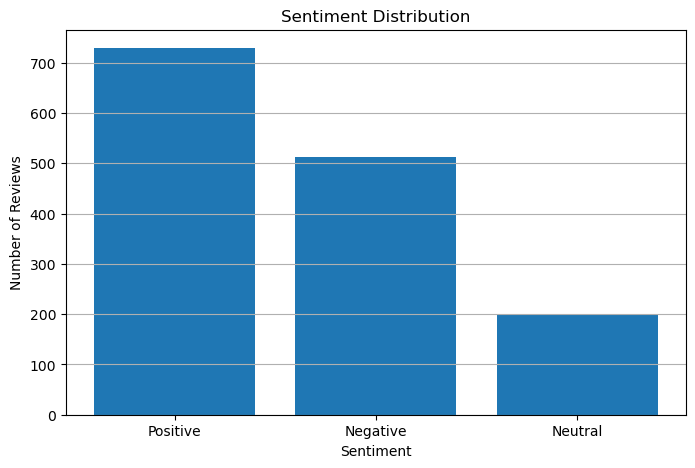

In [20]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")                      # X-axis → categories
plt.ylabel("Number of Reviews")              # Y-axis → frequency

plt.grid(axis='y')
plt.show()

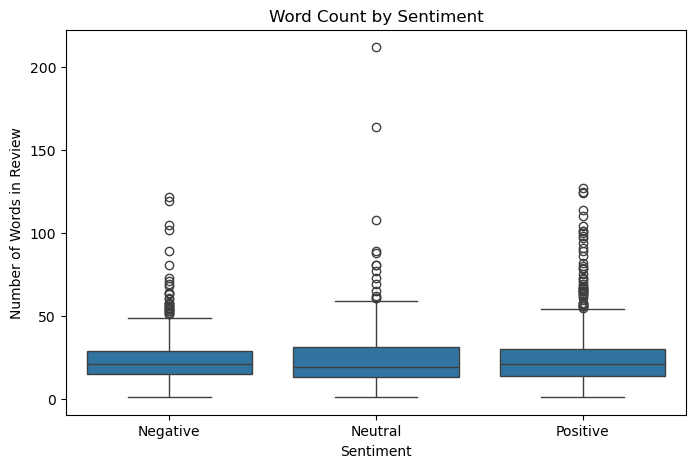

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='sentiment', y='word_count', data=df)

plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words in Review")

plt.show()

# feature Engineering

In [22]:
#from sklearn.feature_extraction.text import TfidfVectorizer

#vectorizer = TfidfVectorizer(
    #max_features=8000,              # increase features
    #ngram_range=(1,2),              # keep this
    #stop_words='english',           # REMOVE noise
    #min_df=2,                       # remove rare words
    #max_df=0.9                      # remove very common words
#)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2),stop_words='english',min_df=2,max_df=0.9)
X = vectorizer.fit_transform(df["clean_review"])

In [24]:
print(df['clean_review'].isnull().sum())
print(df['sentiment'].isnull().sum())

0
0


In [25]:
print(df['sentiment'].dtype)

object


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [27]:
from sklearn.model_selection import train_test_split

y = df['sentiment']

# Step 2: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Print size
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 1152
Testing set size: 288


In [28]:
print(type(X_train))
print(type(y_train))
print(X_train.shape)
print(y_train.shape)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.core.series.Series'>
(1152, 4948)
(1152,)


# Model Building

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

In [30]:
from sklearn.naive_bayes import MultinomialNB

# Train base model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [31]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_search_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_nb.fit(X_train, y_train)

print("Best parameters for Naive Bayes:", grid_search_nb.best_params_)
print("Best F1-macro score for Naive Bayes:", grid_search_nb.best_score_)
nb_model = grid_search_nb.best_estimator_

Best parameters for Naive Bayes: {'alpha': 0.1}
Best F1-macro score for Naive Bayes: 0.5727516548634835


In [32]:
# Cross-validation
from sklearn.model_selection import cross_val_score

cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print("Naive Bayes CV F1 scores:", cv_scores_nb)
print("Mean CV F1 score:", cv_scores_nb.mean())
print("Std Dev:", cv_scores_nb.std())

Naive Bayes CV F1 scores: [0.56135716 0.55595258 0.56158907 0.60185756 0.58300189]
Mean CV F1 score: 0.5727516548634835
Std Dev: 0.01725611722183842



Accuracy: 0.7361111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.81      0.78       102
           1       0.09      0.03      0.04        40
           2       0.78      0.88      0.82       146

    accuracy                           0.74       288
   macro avg       0.54      0.57      0.55       288
weighted avg       0.67      0.74      0.70       288



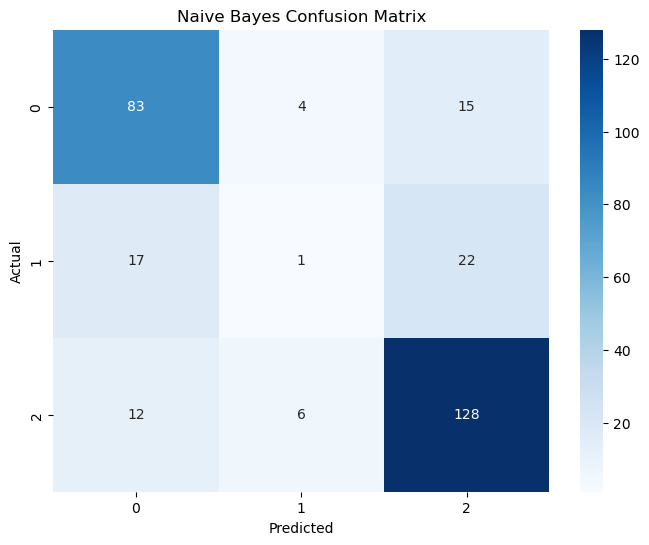

In [33]:
# Testing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_nb = nb_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
from sklearn.svm import LinearSVC

# Train base model
svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [35]:
#Hyperparameter tuning
param_grid_svm = {
    'C': [0.1, 1, 10]
}

grid_search_svm = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid_svm,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best F1-macro score for SVM:", grid_search_svm.best_score_)

svm_model = grid_search_svm.best_estimator_

Best parameters for SVM: {'C': 1}
Best F1-macro score for SVM: 0.6137634222288331


SVM CV F1 scores: [0.58701142 0.61787441 0.61352815 0.59690566 0.65349748]
Mean CV F1 score: 0.6137634222288331
Std Dev: 0.022784226272336183

Accuracy: 0.7361111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.78      0.77       102
           1       0.30      0.17      0.22        40
           2       0.79      0.86      0.82       146

    accuracy                           0.74       288
   macro avg       0.61      0.61      0.60       288
weighted avg       0.71      0.74      0.72       288



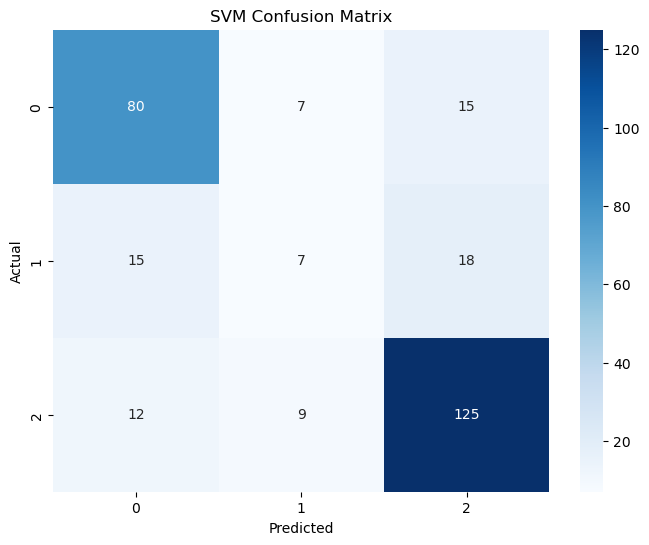

In [36]:
# Cross-validation
cv_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print("SVM CV F1 scores:", cv_scores_svm)
print("Mean CV F1 score:", cv_scores_svm.mean())
print("Std Dev:", cv_scores_svm.std())

# Testing
y_pred_svm = svm_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
#param_grid_lr = {
    #'C': [0.01, 0.1, 1, 5, 10, 20],
    #'solver': ['liblinear', 'saga'],
    #'penalty': ['l2'],   # keep stable
#}

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
log_reg_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [40]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01,0.1, 1, 5,10,20],
    'solver': ['liblinear'],
    'class_weight':[
        'balanced',
        {'negative':1, 'neutral':2, 'positive':1}
    ]    
}

grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV F1 score:", grid_search_lr.best_score_)

# Best model
log_reg_model = grid_search_lr.best_estimator_

Best parameters: {'C': 20, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV F1 score: 0.6126126646000807


In [41]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Scores: [0.594488   0.59656085 0.61352815 0.6107826  0.64770373]
Mean CV Score: 0.6126126646000807
Std Dev: 0.019087872290797024


In [42]:
y_pred = log_reg_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7465277777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77       102
           1       0.32      0.15      0.20        40
           2       0.80      0.88      0.83       146

    accuracy                           0.75       288
   macro avg       0.62      0.61      0.60       288
weighted avg       0.71      0.75      0.72       288



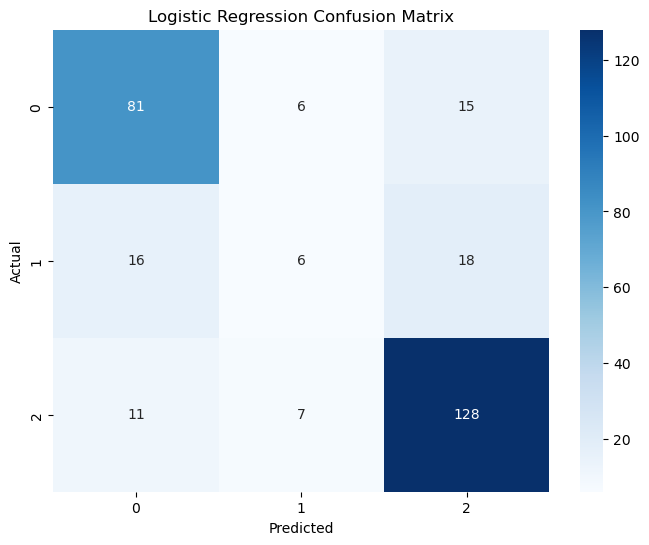

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg_model.classes_,
            yticklabels=log_reg_model.classes_)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [46]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters for RF:", grid_search_rf.best_params_)
print("Best F1-macro score for RF:", grid_search_rf.best_score_)

rf_model = grid_search_rf.best_estimator_

Best parameters for RF: {'max_depth': 10, 'n_estimators': 200}
Best F1-macro score for RF: 0.5637231429902326


In [47]:
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print("RF CV F1 scores:", cv_scores_rf)
print("Mean CV F1 score:", cv_scores_rf.mean())

y_pred_rf = rf_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

RF CV F1 scores: [0.58878697 0.51694276 0.5274     0.5875987  0.59788729]
Mean CV F1 score: 0.5637231429902326

Accuracy: 0.71875

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       102
           1       0.18      0.05      0.08        40
           2       0.77      0.84      0.80       146

    accuracy                           0.72       288
   macro avg       0.55      0.57      0.54       288
weighted avg       0.66      0.72      0.68       288



In [48]:
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(C=1, max_iter=1000, class_weight='balanced'),
    "SVM": LinearSVC(C=1, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
}

In [49]:
results = []

for name, model in models.items():
    print(f"Running {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    print(f"{name} Done\n")

Running Naive Bayes...
Naive Bayes Done

Running Logistic Regression...
Logistic Regression Done

Running SVM...
SVM Done

Running Random Forest...
Random Forest Done



In [50]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score
0,Naive Bayes,0.736111,0.697466
1,Logistic Regression,0.715278,0.706450
2,SVM,0.736111,0.718892
3,Random Forest,0.729167,0.676925


In [51]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,F1 Score
2,SVM,0.736111,0.718892
1,Logistic Regression,0.715278,0.706450
0,Naive Bayes,0.736111,0.697466
3,Random Forest,0.729167,0.676925


In [52]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(svm_model, "svm_model.pkl")

print("NLP model files saved!")

NLP model files saved!
